In [4]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_binary_5050split_health_indicators_BRFSS2015.csv to diabetes_binary_5050split_health_indicators_BRFSS2015 (1).csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42

In [6]:
DATA_FILE = "diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

df = pd.read_csv(DATA_FILE)
print("Shape:", df.shape)
df.head()

Shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [9]:
target_col = "Diabetes_012" if "Diabetes_012" in df.columns else "Diabetes_binary"
print("Target column:", target_col)
print(df[target_col].value_counts(normalize=True).round(4) * 100, "%")

Target column: Diabetes_binary
Diabetes_binary
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64 %


In [10]:
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
missing[missing > 0]

Total missing values: 0


,0


In [11]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} ({n_dupes/len(df):.2%} of data)")

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 1635 (2.31% of data)
Shape after dropping duplicates: (69057, 22)


In [12]:
checks = {
    "BMI": (df["BMI"].between(10, 100)).all(),
    "MentHlth": (df["MentHlth"].between(0, 30)).all(),
    "PhysHlth": (df["PhysHlth"].between(0, 30)).all(),
    "GenHlth": (df["GenHlth"].between(1, 5)).all(),
    "Age": (df["Age"].between(1, 13)).all(),
}
checks

{'BMI': np.True_,
 'MentHlth': np.True_,
 'PhysHlth': np.True_,
 'GenHlth': np.True_,
 'Age': np.True_}

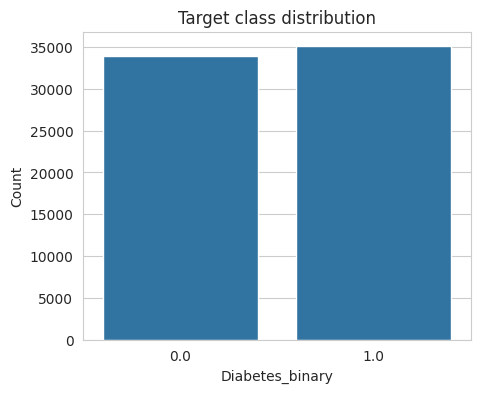

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x=df[target_col])
plt.title("Target class distribution")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.show()

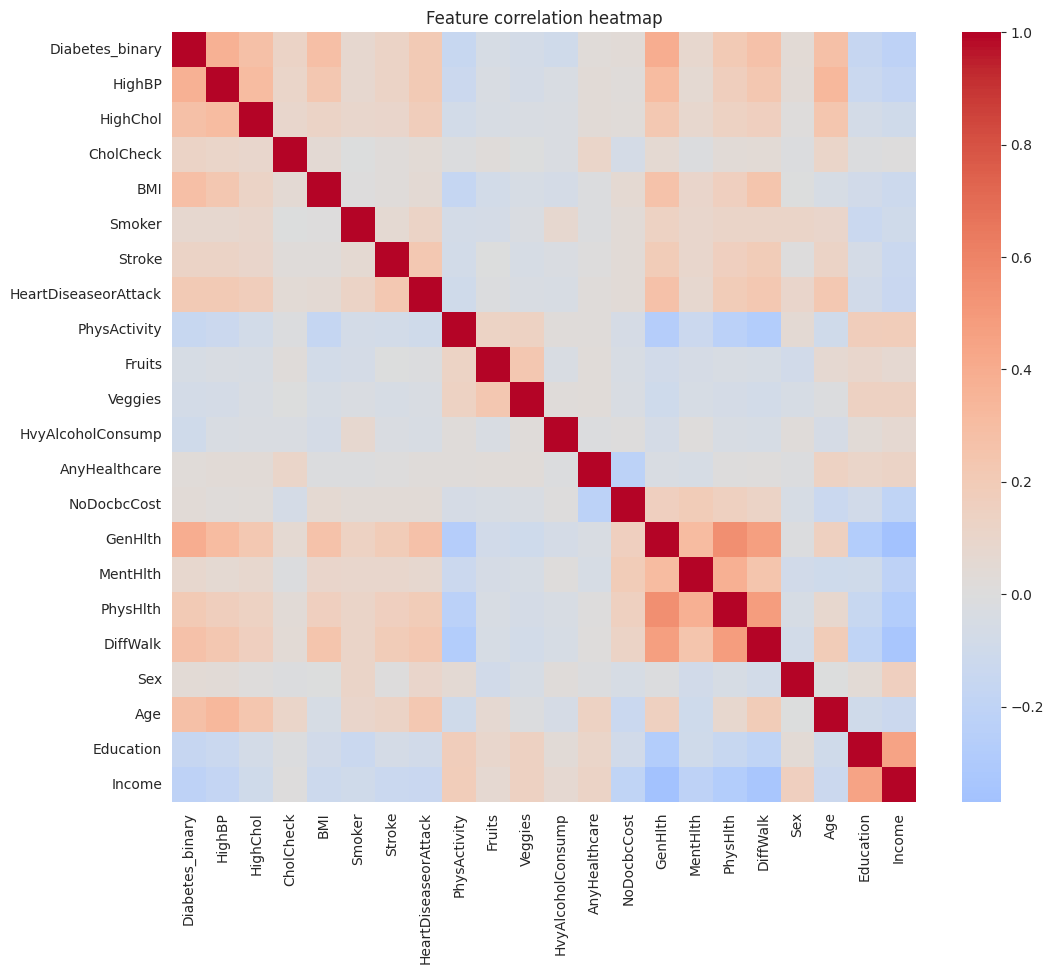

,Diabetes_binary
GenHlth,0.396571
HighBP,0.372048
BMI,0.285643
HighChol,0.281399
Age,0.274550
DiffWalk,0.267082
Income,-0.212846
HeartDiseaseorAttack,0.207229
PhysHlth,0.206868
Education,-0.158522


In [14]:
plt.figure(figsize=(12,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation heatmap")
plt.show()

corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)

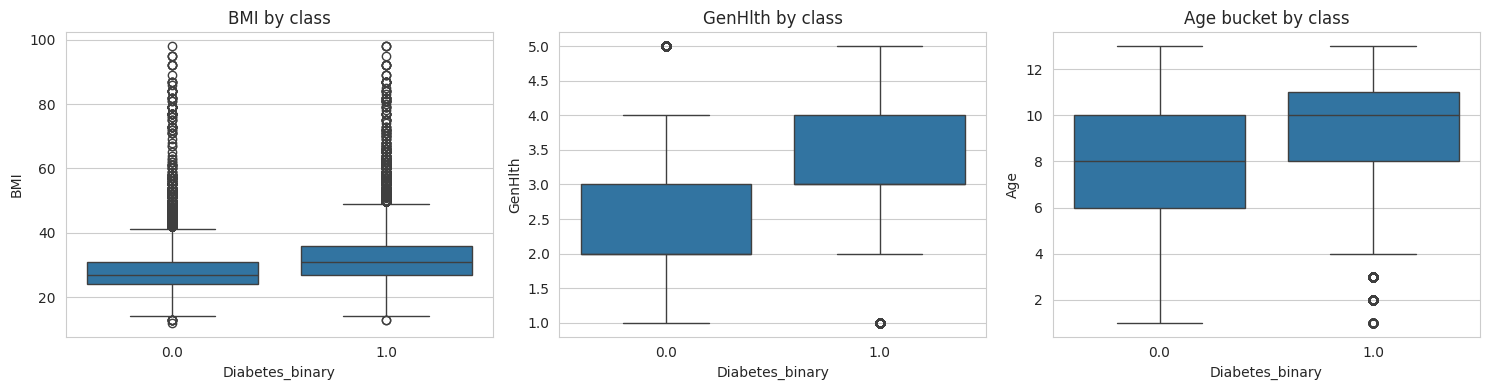

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(x=df[target_col], y=df["BMI"], ax=axes[0]); axes[0].set_title("BMI by class")
sns.boxplot(x=df[target_col], y=df["GenHlth"], ax=axes[1]); axes[1].set_title("GenHlth by class")
sns.boxplot(x=df[target_col], y=df["Age"], ax=axes[2]); axes[2].set_title("Age bucket by class")
plt.tight_layout()
plt.show()

In [16]:
if target_col == "Diabetes_012":
    print("3-class file detected — merging Prediabetes into Diabetes.")
    df["Diabetes_binary"] = df["Diabetes_012"].replace({1: 1, 2: 1})
    df = df.drop(columns=["Diabetes_012"])
    target_col = "Diabetes_binary"
else:
    print("Binary file detected — already merged/balanced.")

print(df[target_col].value_counts())

Binary file detected — already merged/balanced.
Diabetes_binary
1.0    35097
0.0    33960
Name: count, dtype: int64


In [17]:
feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (55245, 21)  Test: (13812, 21)


In [18]:
train_df = X_train.copy()
train_df[target_col] = y_train.values

class_counts = train_df[target_col].value_counts()
minority_class = class_counts.idxmin()
majority_class = class_counts.idxmax()
n_minority = class_counts.min()

if class_counts.min() / class_counts.max() < 0.9:
    majority_df = train_df[train_df[target_col] == majority_class].sample(
        n=n_minority, random_state=RANDOM_STATE
    )
    minority_df = train_df[train_df[target_col] == minority_class]
    train_balanced = pd.concat([majority_df, minority_df]).sample(
        frac=1, random_state=RANDOM_STATE
    ).reset_index(drop=True)
    print("Applied undersampling.")
else:
    train_balanced = train_df.reset_index(drop=True)
    print("Already balanced — no undersampling needed.")

print(train_balanced[target_col].value_counts())

X_train = train_balanced.drop(columns=[target_col])
y_train = train_balanced[target_col]

Already balanced — no undersampling needed.
Diabetes_binary
1.0    28077
0.0    27168
Name: count, dtype: int64


In [19]:
def engineer_features(df_in):
    df_out = df_in.copy()

    df_out["BMI_Category"] = pd.cut(
        df_out["BMI"],
        bins=[0, 18.5, 25, 30, 100],
        labels=["Underweight", "Normal", "Overweight", "Obese"]
    )

    df_out["UnhealthyDays"] = (df_out["MentHlth"] + df_out["PhysHlth"]).clip(upper=30)

    df_out["ComorbidityCount"] = (
        df_out["HighBP"] + df_out["HighChol"] +
        df_out["Stroke"] + df_out["HeartDiseaseorAttack"]
    )

    df_out["PoorGenHlth"] = (df_out["GenHlth"] >= 4).astype(int)

    df_out["LifestyleScore"] = (
        df_out["PhysActivity"] + df_out["Fruits"] + df_out["Veggies"]
        - df_out["HvyAlcoholConsump"]
    )

    df_out["CareAccessGap"] = (
        (df_out["AnyHealthcare"] == 1) & (df_out["NoDocbcCost"] == 1)
    ).astype(int)

    df_out["BMI_Age_Interaction"] = df_out["BMI"] * df_out["Age"]

    return df_out

X_train_fe = engineer_features(X_train)
X_test_fe = engineer_features(X_test)

X_train_fe.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,BMI_Category,UnhealthyDays,ComorbidityCount,PoorGenHlth,LifestyleScore,CareAccessGap,BMI_Age_Interaction
0,1.0,1.0,1.0,40.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,4.0,21.0,14.0,0.0,0.0,7.0,5.0,7.0,Obese,30.0,2.0,1,2.0,0,280.0
1,1.0,1.0,1.0,47.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,30.0,14.0,1.0,0.0,6.0,3.0,1.0,Obese,30.0,3.0,0,2.0,0,282.0
2,0.0,0.0,1.0,24.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,7.0,5.0,7.0,Normal,3.0,0.0,0,1.0,0,168.0
3,1.0,1.0,1.0,42.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,9.0,5.0,7.0,Obese,0.0,2.0,0,1.0,0,378.0
4,0.0,0.0,1.0,35.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,3.0,6.0,0.0,1.0,0.0,9.0,5.0,6.0,Obese,6.0,0.0,0,2.0,0,315.0


In [20]:
X_train_fe = pd.get_dummies(X_train_fe, columns=["BMI_Category"], drop_first=False)
X_test_fe = pd.get_dummies(X_test_fe, columns=["BMI_Category"], drop_first=False)

X_train_fe, X_test_fe = X_train_fe.align(X_test_fe, join="left", axis=1, fill_value=0)

print(X_train_fe.shape, X_test_fe.shape)

(55245, 31) (13812, 31)


In [21]:
continuous_cols = ["BMI", "MentHlth", "PhysHlth", "UnhealthyDays", "BMI_Age_Interaction"]

scaler = StandardScaler()
X_train_fe[continuous_cols] = scaler.fit_transform(X_train_fe[continuous_cols])
X_test_fe[continuous_cols] = scaler.transform(X_test_fe[continuous_cols])

X_train_fe[continuous_cols].describe().T[["mean", "std"]]

,mean,std
BMI,-2.366547e-16,1.000009
MentHlth,4.527306e-17,1.000009
PhysHlth,-9.131783e-17,1.000009
UnhealthyDays,-5.324730e-17,1.000009
BMI_Age_Interaction,-5.620548e-17,1.000009


In [22]:
os.makedirs("processed_data", exist_ok=True)

X_train_fe.to_csv("processed_data/X_train.csv", index=False)
X_test_fe.to_csv("processed_data/X_test.csv", index=False)
y_train.to_csv("processed_data/y_train.csv", index=False)
y_test.to_csv("processed_data/y_test.csv", index=False)

joblib.dump(scaler, "processed_data/scaler.pkl")

print("Saved:")
for f in os.listdir("processed_data"):
    print(" -", f)

Saved:
 - y_test.csv
 - X_test.csv
 - y_train.csv
 - scaler.pkl
 - X_train.csv
